# Generalized Additive Models

This notebook is a compact GAM walkthrough for the lecture notes. It does four concrete things:

1. It creates a small synthetic demand dataset and stores it in `data/`.
2. It fits two regressors on a hold-out split: a linear ridge baseline and a GAM-style additive spline model.
3. It visualizes why the GAM fits better when each feature has its own smooth, nonlinear effect.
4. It explains one prediction as an intercept plus feature-level contributions and exports all figures and tables to `out/`.

The example is deliberately additive: temperature has a curved effect, marketing has diminishing returns, and discount saturates. That makes it easy to see what a GAM is actually buying over a plain linear model.
        


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT / "xai_book").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = Path("data")
NOTEBOOK_SLUG = "generalized_additive_models"
OUT_DIR = Path("out") / NOTEBOOK_SLUG
OUT_DIR.mkdir(parents=True, exist_ok=True)


def out_path(filename: str) -> Path:
    return OUT_DIR / filename


def save_table(frame, filename: str) -> Path:
    path = out_path(filename)
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path)
    print(f"saved: {path}")
    return path
        


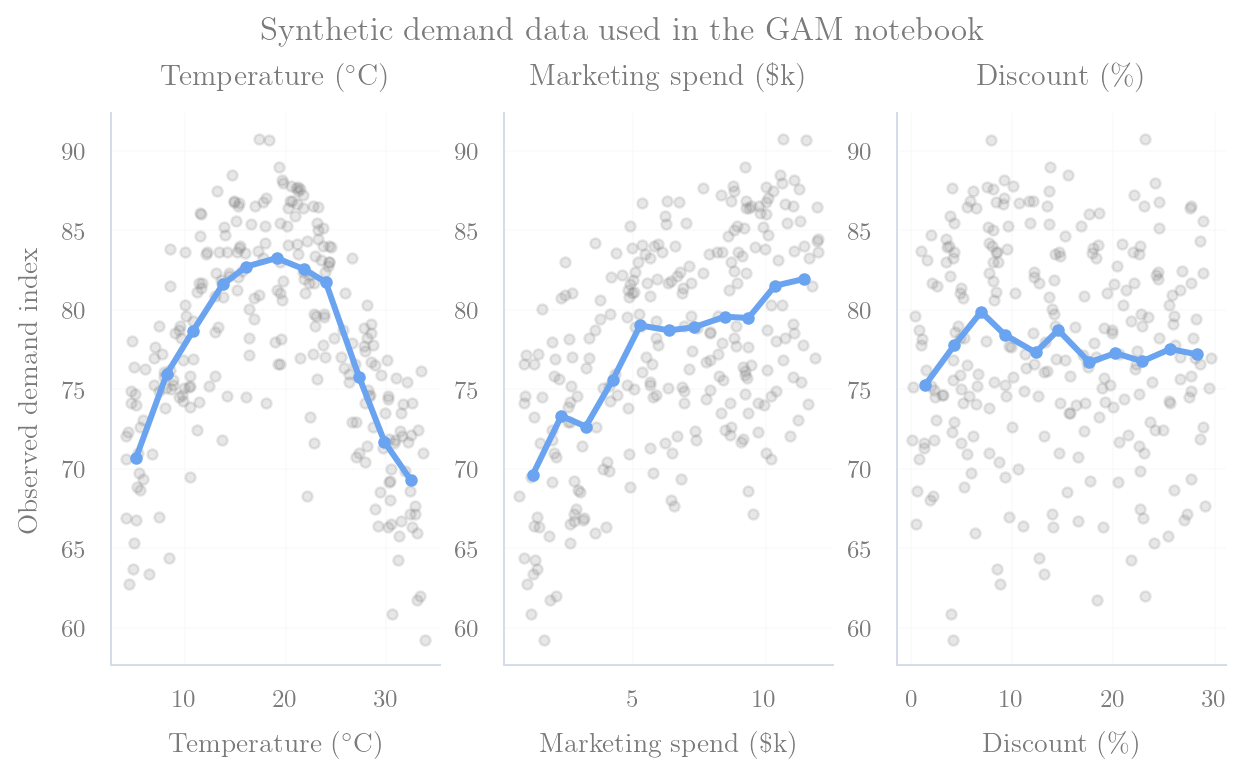

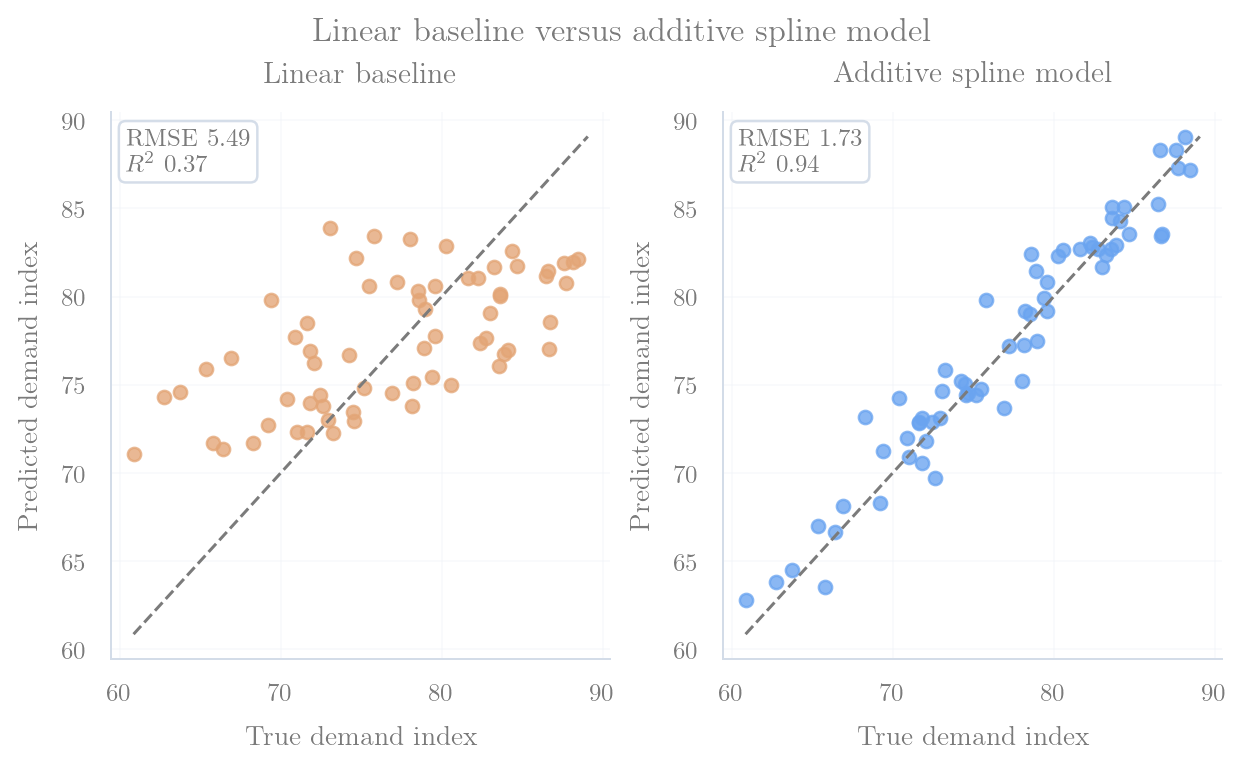

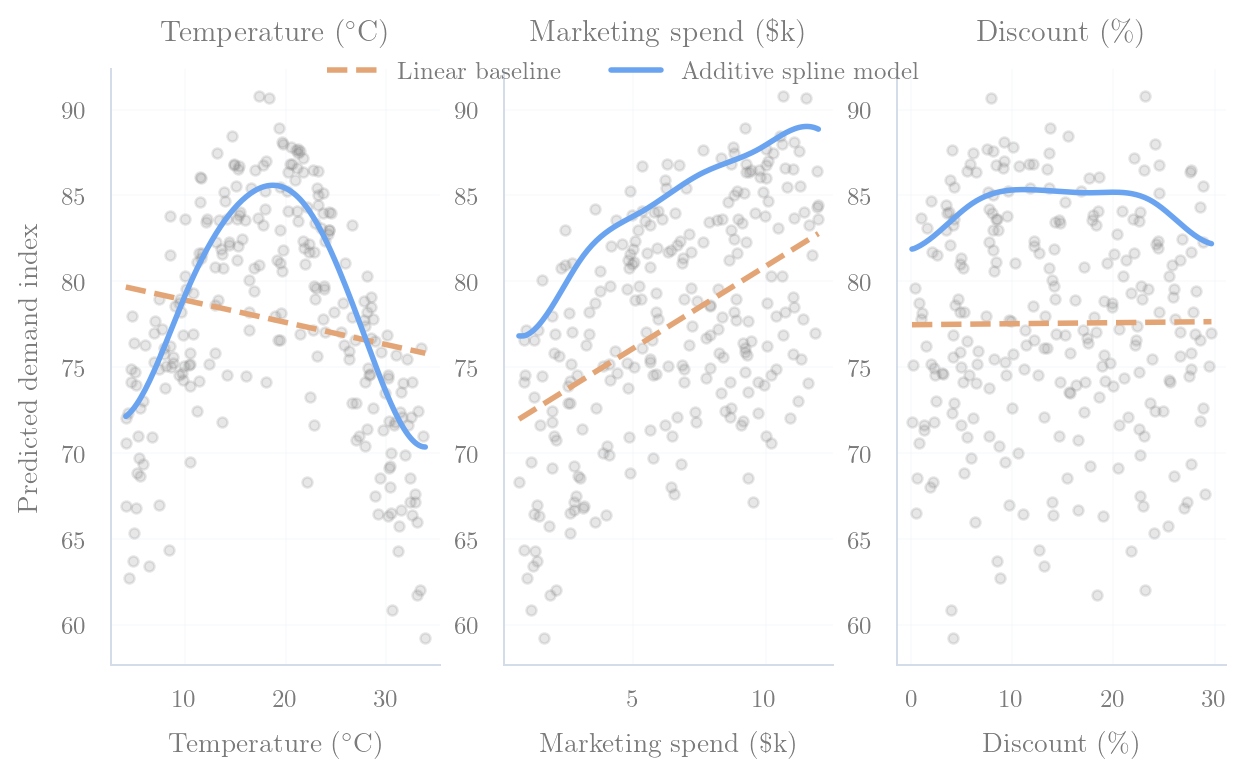

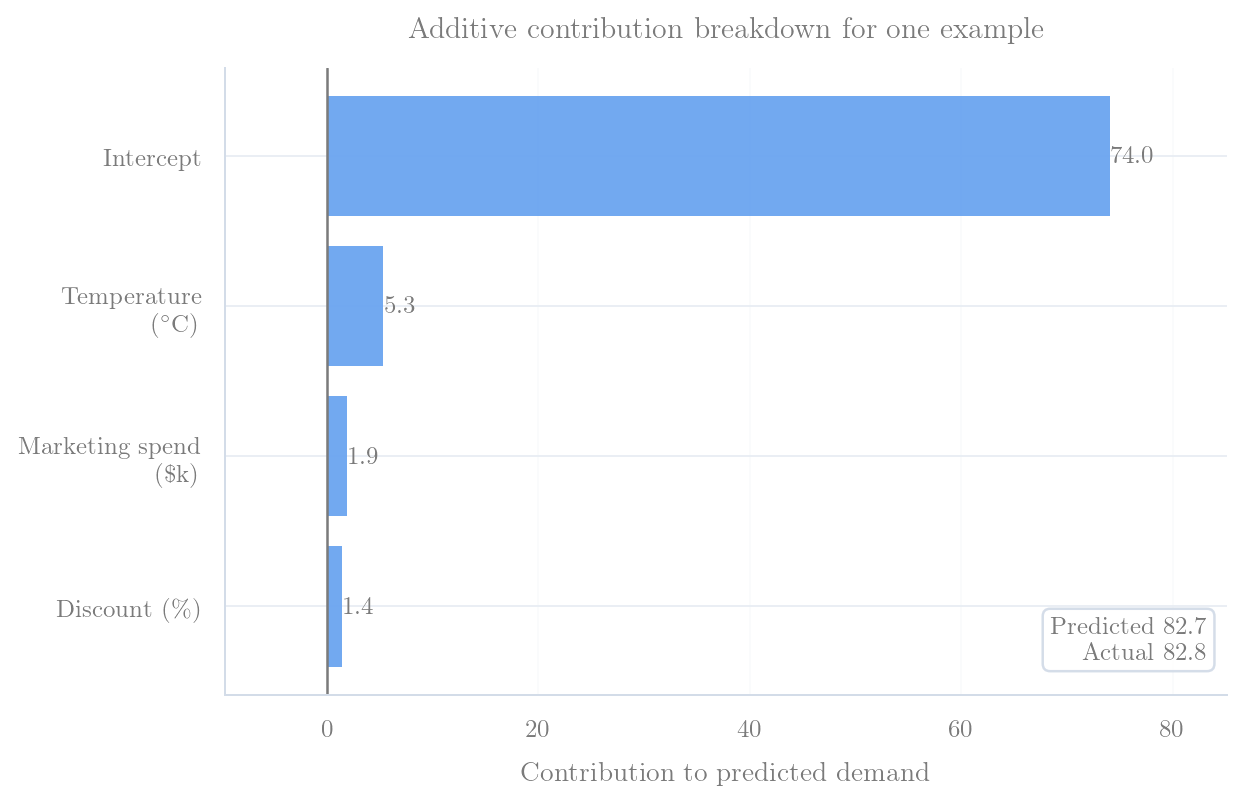

In [2]:
from IPython.display import display
import pandas as pd

from xai_book.gam_models import (
    GAM_FIGURE_FILENAMES,
    GAM_TABLE_FILENAMES,
    ensure_gam_demo_dataset,
    run_gam_regression_analysis,
)
from xai_book.plotting import display_and_save_figure

DATA_PATH = DATA_DIR / "gam_synthetic_regression.csv"
dataset = ensure_gam_demo_dataset(DATA_PATH, random_state=7)
analysis = run_gam_regression_analysis(
    data_path=DATA_PATH,
    test_size=0.25,
    random_state=7,
)

metric_frame = analysis["metrics"].set_index("model").round(3)
breakdown_frame = analysis["breakdown_frame"].copy()
breakdown_table = breakdown_frame[["term", "contribution"]].set_index("term").round(2)

linear_rmse = float(metric_frame.loc["Linear baseline", "RMSE"])
gam_rmse = float(metric_frame.loc["Additive spline model", "RMSE"])
rmse_gain_pct = 100.0 * (linear_rmse - gam_rmse) / linear_rmse


def show_and_save(name: str) -> Path:
    path = display_and_save_figure(
        analysis["figures"][name],
        out_path(f"{GAM_FIGURE_FILENAMES[name]}.pdf"),
    )
    print(f"saved: {path}")
    return path
        


## 1. Setup And Modeling Choices

The synthetic target is a demand index. The notebook uses three input features and compares two models on the same train/test split:

- `Temperature (°C)`: allowed to have a curved seasonal effect.
- `Marketing spend ($k)`: allowed to have diminishing returns.
- `Discount (%)`: allowed to help at first and then flatten out.
- Linear baseline: one global straight-line coefficient per feature.
- Additive spline model: one smooth spline basis per feature, then a ridge model on top.

The GAM stays interpretable because it is still additive: each feature contributes through its own one-dimensional curve.
        


In [3]:
setup_frame = pd.Series(
    {
        "data_path": str(DATA_PATH),
        "rows": len(dataset),
        "train_rows": len(analysis["x_train"]),
        "test_rows": len(analysis["x_test"]),
    },
    name="value",
).to_frame()

model_frame = pd.DataFrame(
    {
        "component": [
            "Target",
            "Baseline",
            "GAM",
            "Explanation",
        ],
        "description": [
            "Synthetic demand index with nonlinear additive effects",
            "Standardized ridge regression with one linear term per feature",
            "One spline basis per feature plus ridge regression on the expanded design",
            "Aggregate spline-basis coefficients back to feature-level contributions",
        ],
    }
)

display(setup_frame)
display(model_frame)
        


,value
data_path,data/gam_synthetic_regression.csv
rows,260
train_rows,195
test_rows,65


,component,description
0,Target,Synthetic demand index with nonlinear additive...
1,Baseline,Standardized ridge regression with one linear ...
2,GAM,One spline basis per feature plus ridge regres...
3,Explanation,Aggregate spline-basis coefficients back to fe...


## 2. Synthetic Data Structure

The next figure shows the actual data used for the demo. Each panel is one feature against the observed target. The gray cloud is the raw sample, and the blue line is a simple binned average trend.

This is the key reason the GAM is useful here: the feature-response shape is not a straight line.
        


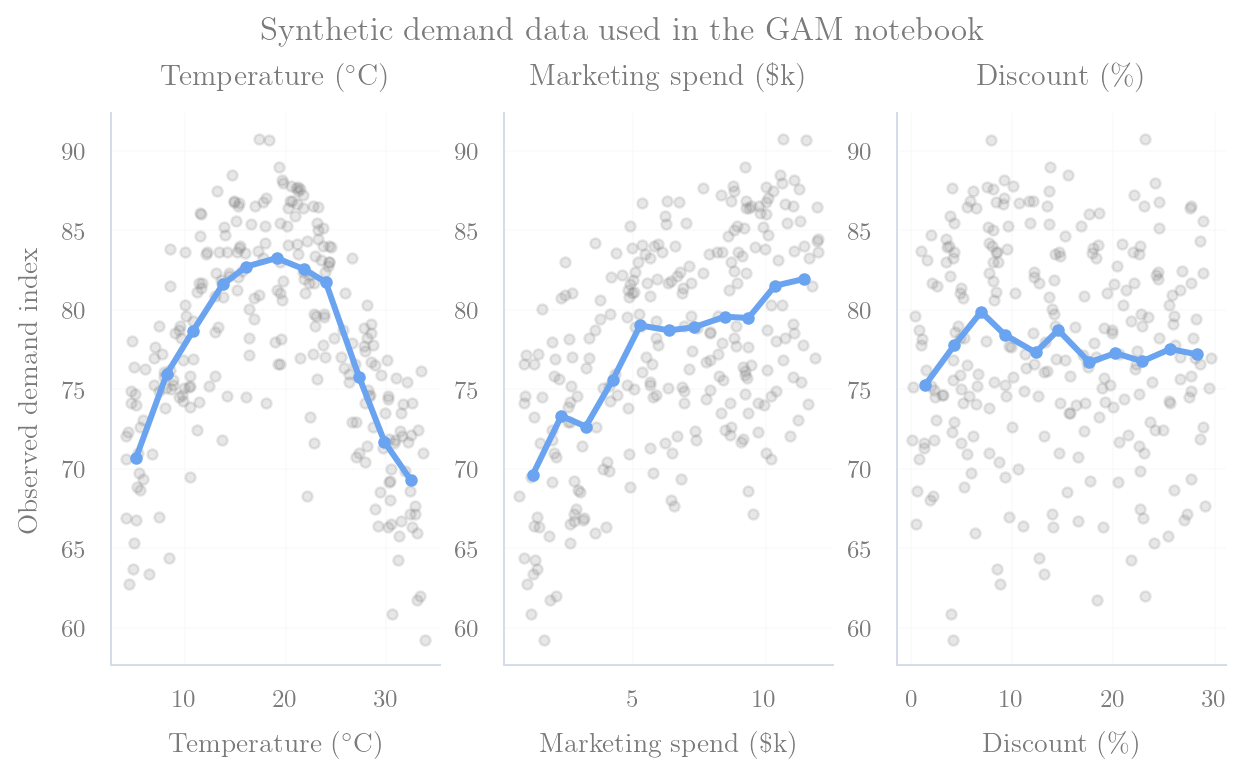

saved: out/generalized_additive_models/gam_data_overview.pdf


PosixPath('out/generalized_additive_models/gam_data_overview.pdf')

In [4]:
show_and_save("data_overview")
        


## 3. Held-Out Model Comparison

A GAM should only be preferred if it improves prediction on unseen data, not just because the curves look nicer. The table and figure below compare the linear baseline and the additive spline model on the same test split.
        


,RMSE,MAE,R2
model,,,
Linear baseline,5.493,4.547,0.372
Additive spline model,1.730,1.352,0.938


,value
Linear RMSE,5.493
GAM RMSE,1.730
RMSE improvement (%),68.500


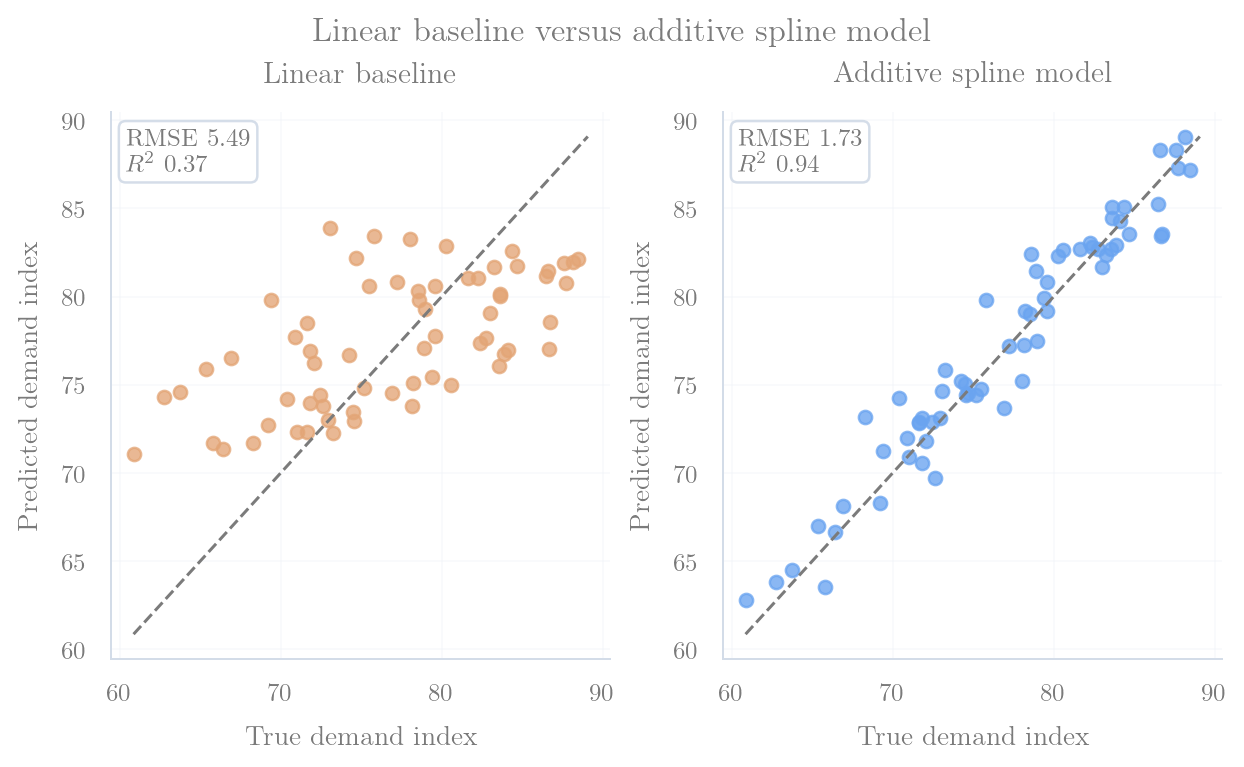

saved: out/generalized_additive_models/gam_model_comparison.pdf


PosixPath('out/generalized_additive_models/gam_model_comparison.pdf')

In [5]:
gain_frame = pd.Series(
    {
        "Linear RMSE": round(linear_rmse, 3),
        "GAM RMSE": round(gam_rmse, 3),
        "RMSE improvement (%)": round(rmse_gain_pct, 1),
    },
    name="value",
).to_frame()

display(metric_frame)
display(gain_frame)
show_and_save("model_comparison")
        


## 4. Smooth Feature Effects

This plot is the core GAM visualization. For each feature, the dashed orange line is what the linear model can express, while the solid blue line is the GAM effect curve with the other features fixed at a typical value.

A good GAM figure should make the inductive bias visible at a glance: one smooth curve per feature, added together in the final prediction.
        


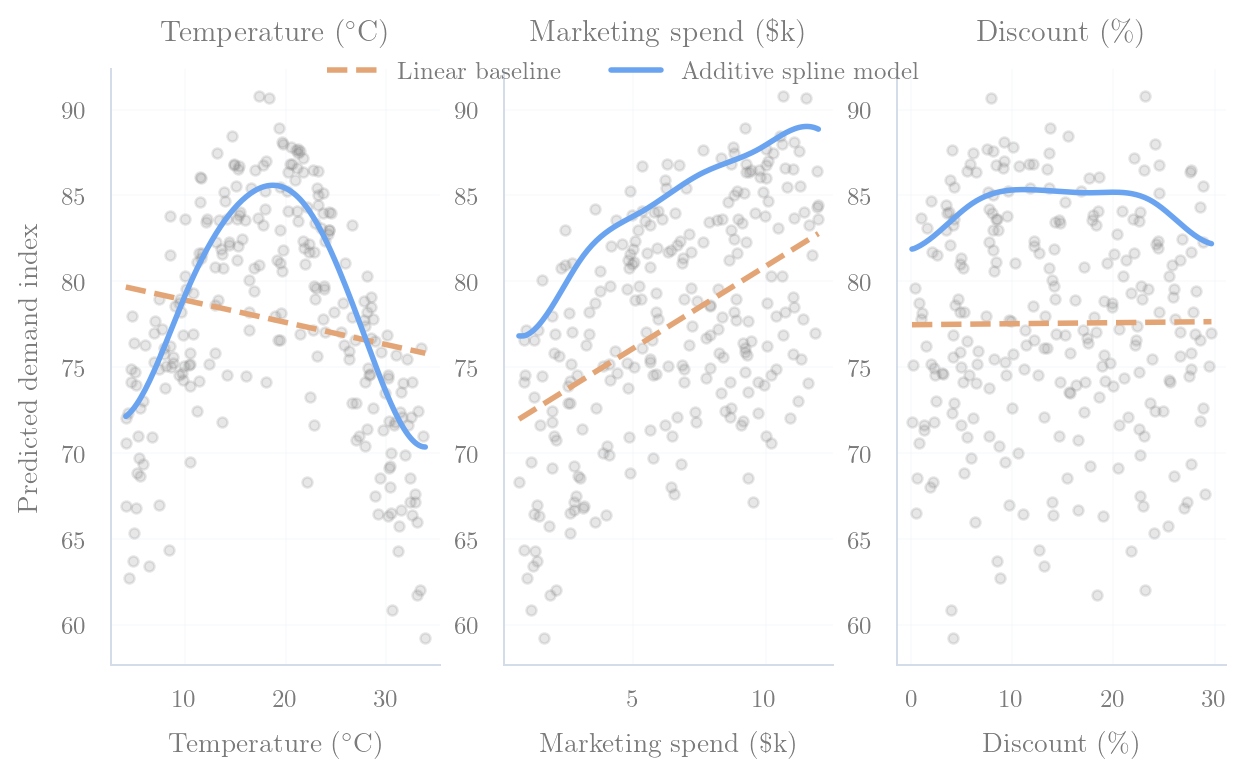

saved: out/generalized_additive_models/gam_feature_effects.pdf


PosixPath('out/generalized_additive_models/gam_feature_effects.pdf')

In [6]:
show_and_save("feature_effects")
        


## 5. One Prediction As Additive Parts

Because the model is additive, one prediction can be written as:

$\text{prediction} = \text{intercept} + \text{temperature effect} + \text{marketing effect} + \text{discount effect}$

The final figure shows exactly that decomposition for one well-predicted test example.
        


saved: out/generalized_additive_models/gam_metrics.csv
saved: out/generalized_additive_models/gam_prediction_breakdown.csv


,contribution
term,
Intercept,74.03
Temperature ($^\circ$C),5.33
Marketing spend (\$k),1.91
Discount (\%),1.42
Prediction,82.69


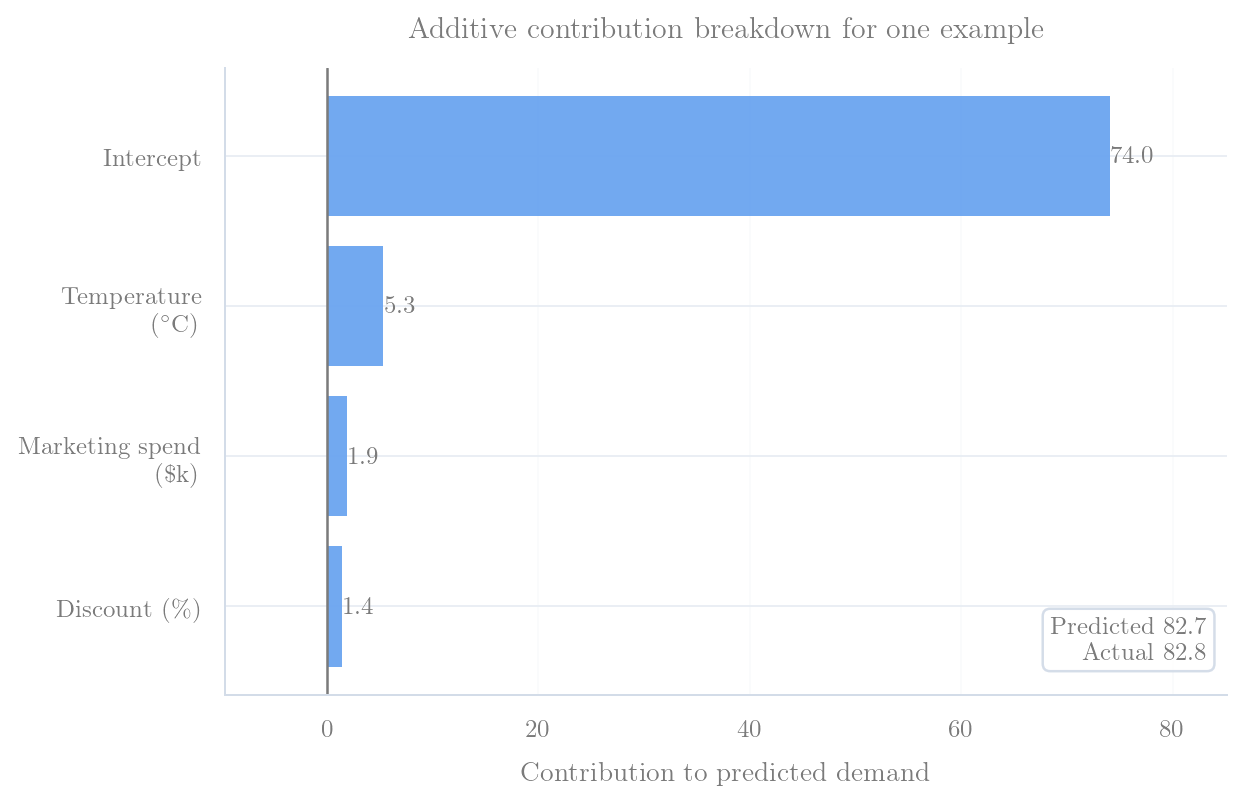

saved: out/generalized_additive_models/gam_prediction_breakdown.pdf


PosixPath('out/generalized_additive_models/gam_prediction_breakdown.pdf')

In [7]:
save_table(metric_frame, f"{GAM_TABLE_FILENAMES['metrics']}.csv")
save_table(breakdown_table, f"{GAM_TABLE_FILENAMES['prediction_breakdown']}.csv")

display(breakdown_table)
show_and_save("prediction_breakdown")
        
